In [1]:
%pip install pandas scikit-learn flask flask-cors joblib numpy matplotlib seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 4.4 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.3 MB 4.3 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.3 MB 4.8 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.3 MB 5.3 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.3 MB 5.9 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 6.6 MB/s  0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached c


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a premium, modern theme for our visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0})

print("Loading UCI Heart Disease Dataset...")
url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
df = pd.read_csv(url)

# Display the first few rows to confirm it loaded
df.head()

Loading UCI Heart Disease Dataset...


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
print("=== Dataset Shape ===")
print(f"Total Patients: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}\n")

print("=== Missing Values Check ===")
print(df.isnull().sum())

print("\n=== Statistical Summary ===")
display(df.describe().T)


=== Dataset Shape ===
Total Patients: 303
Total Features: 14

=== Missing Values Check ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


C:\Users\burla\AppData\Local\Temp\ipykernel_24404\3992242415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df, palette=['#ef4444', '#10b981'])


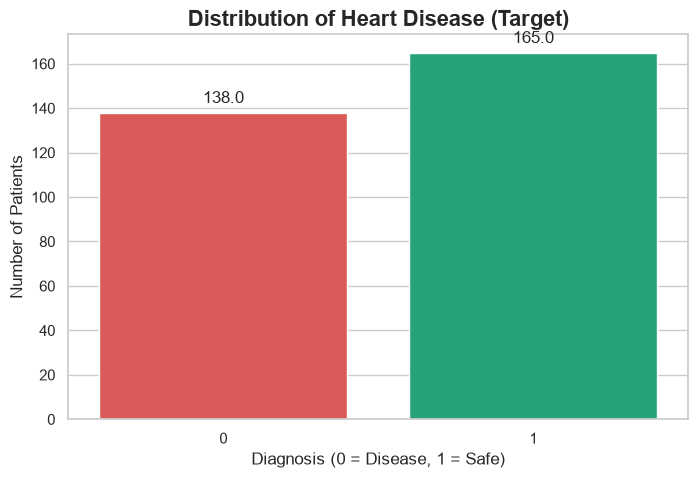

In [4]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='target', data=df, palette=['#ef4444', '#10b981'])

plt.title('Distribution of Heart Disease (Target)', fontsize=16, fontweight='bold')
plt.xlabel('Diagnosis (0 = Disease, 1 = Safe)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

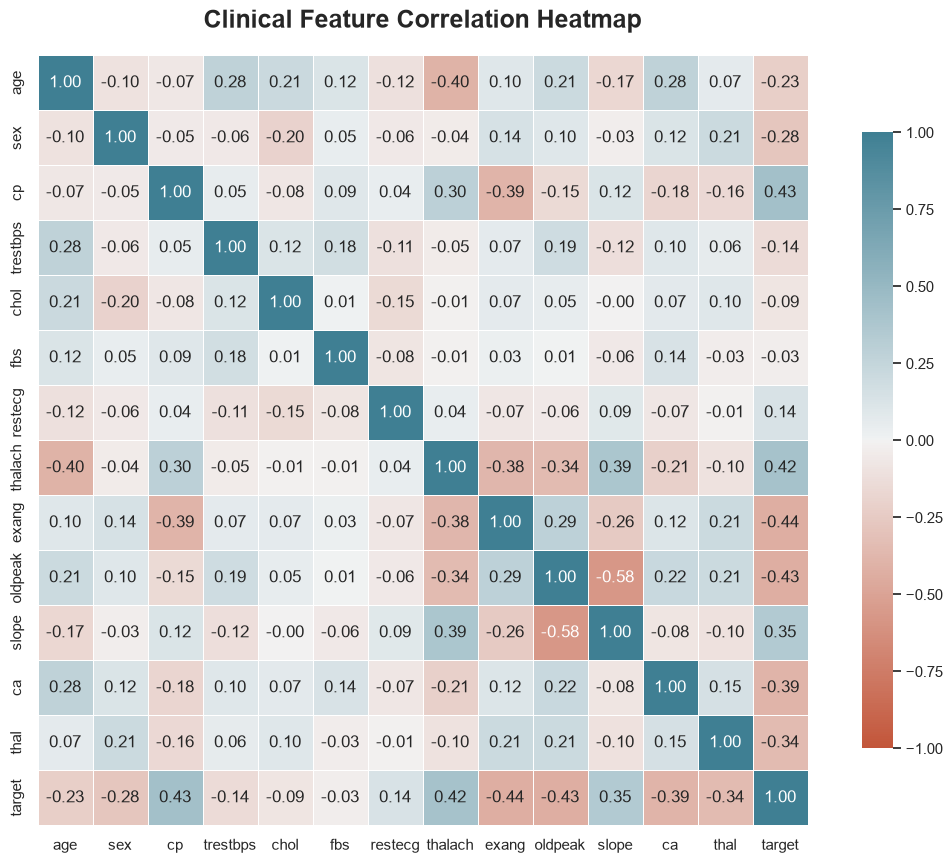

In [5]:
plt.figure(figsize=(14, 10))

# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a custom diverging color map
cmap = sns.diverging_palette(20, 220, as_cmap=True)

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=cmap, vmin=-1, vmax=1, 
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Clinical Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.show()

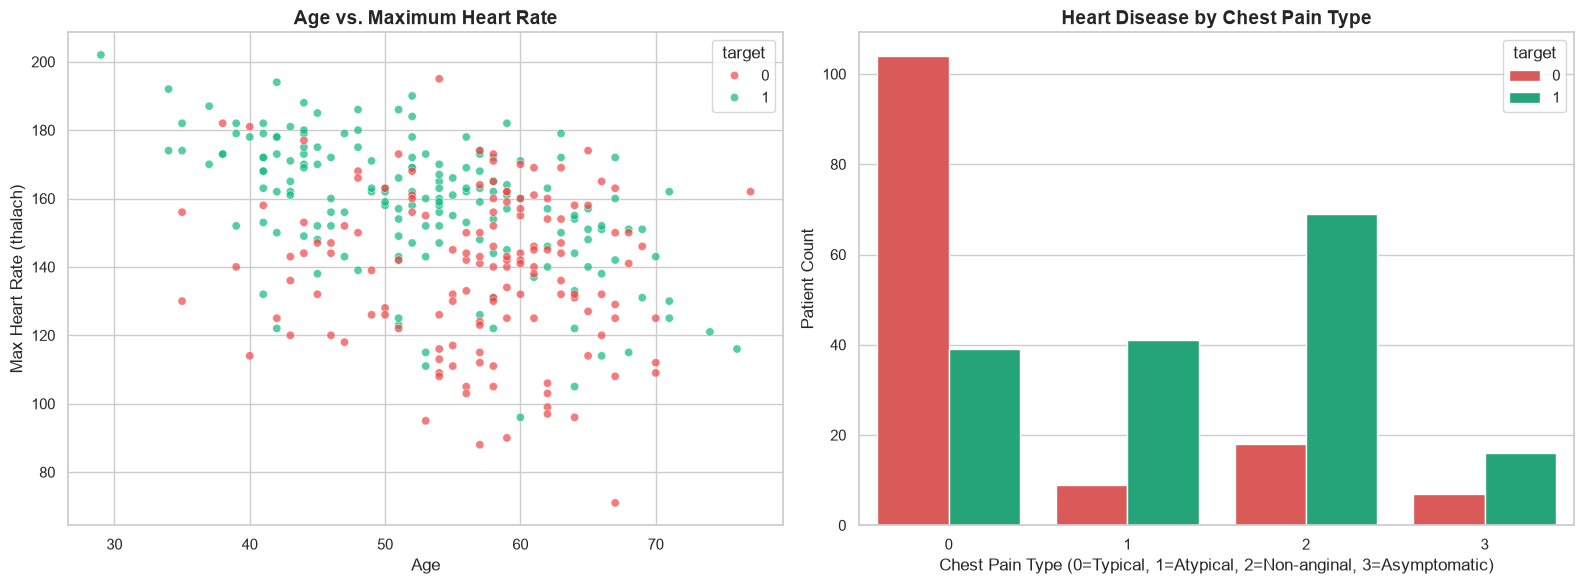

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Age vs Max Heart Rate
sns.scatterplot(x='age', y='thalach', hue='target', data=df, 
                palette=['#ef4444', '#10b981'], alpha=0.7, ax=axes[0])
axes[0].set_title('Age vs. Maximum Heart Rate', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Max Heart Rate (thalach)')

# Plot 2: Chest Pain Type Distribution
sns.countplot(x='cp', hue='target', data=df, palette=['#ef4444', '#10b981'], ax=axes[1])
axes[1].set_title('Heart Disease by Chest Pain Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Chest Pain Type (0=Typical, 1=Atypical, 2=Non-anginal, 3=Asymptomatic)')
axes[1].set_ylabel('Patient Count')

plt.tight_layout()
plt.show()